# SIR model: forward Euler simulation

Simulates the SIR model
$$
\frac{dS}{dt} = -\beta S I, \qquad
\frac{dI}{dt} = \beta S I - \gamma I, \qquad
\frac{dR}{dt} = \gamma I,
$$
with a simple forward Euler solver, for three choices of $(\beta,\gamma)$ and a common initial condition of 95% susceptible and 5% infected.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def forward_euler_sir(beta, gamma, S0, I0, R0, T, dt):
    """Forward Euler solver for the SIR model."""
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps + 1)
    S = np.zeros(n_steps + 1)
    I = np.zeros(n_steps + 1)
    R = np.zeros(n_steps + 1)
    S[0], I[0], R[0] = S0, I0, R0

    for k in range(n_steps):
        dS = -beta * S[k] * I[k]
        dI = beta * S[k] * I[k] - gamma * I[k]
        dR = gamma * I[k]
        S[k + 1] = S[k] + dt * dS
        I[k + 1] = I[k] + dt * dI
        R[k + 1] = R[k] + dt * dR

    return t, S, I, R

In [3]:
# common initial condition: 95% susceptible, 5% infected, 0% recovered
S0, I0, R0 = 0.95, 0.05, 0.0
T, dt = 100.0, 0.05

# three choices of (beta, gamma), reported via the basic reproduction number R0 = beta*S0/gamma
params = [
    (0.4, 0.1),
    (0.2, 0.1),
    (0.1, 0.2),
]

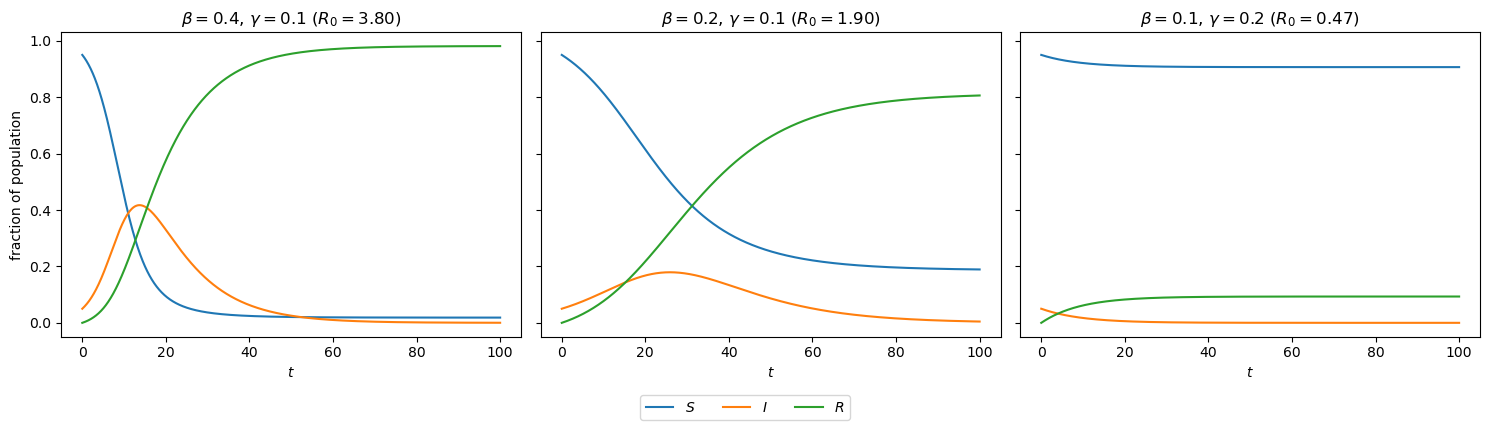

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (beta, gamma) in zip(axes, params):
    t, S, I, R = forward_euler_sir(beta, gamma, S0, I0, R0, T, dt)
    R_eff = beta * S0 / gamma

    ax.plot(t, S, label="$S$")
    ax.plot(t, I, label="$I$")
    ax.plot(t, R, label="$R$")
    ax.set_xlabel("$t$")
    ax.set_title(f"$\\beta={beta}$, $\\gamma={gamma}$ ($R_0={R_eff:.2f}$)")

axes[0].set_ylabel("fraction of population")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
fig.savefig("sir_dynamics.png", dpi=300, bbox_inches="tight")
plt.show()